In [100]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [101]:
df = pd.read_excel("data/raw/Telco_customer_churn.xlsx")

In [102]:
df_clean = df.copy()

In [103]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [104]:
df_clean.head(2)

,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved


In [105]:
df_clean.drop_duplicates(inplace=True)

print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 0


In [106]:
missing = pd.DataFrame({
    "Missing": df_clean.isnull().sum(),
    "Percentage": round(df_clean.isnull().mean()*100,2)
})

missing.sort_values("Percentage", ascending=False)

,Missing,Percentage
churn_reason,5174,73.46
customer_id,0,0.00
count,0,0.00
state,0,0.00
country,0,0.00
zip_code,0,0.00
lat_long,0,0.00
latitude,0,0.00
city,0,0.00
gender,0,0.00


In [107]:
# Handle Missing Values

# Numerical columns
for col in df_clean.select_dtypes(include="number"):
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Object & Category columns
for col in df_clean.select_dtypes(include=["object", "category"]):

    if df_clean[col].isnull().sum() > 0:

        mode = df_clean[col].mode()

        if not mode.empty:
            df_clean[col] = df_clean[col].fillna(mode.iloc[0])

print("Missing Values Remaining:")
print(df_clean.isnull().sum())

Missing Values Remaining:
customer_id          0
count                0
country              0
state                0
city                 0
zip_code             0
lat_long             0
latitude             0
longitude            0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn_label          0
churn_value          0
churn_score          0
cltv                 0
churn_reason         0
dtype: int64


In [108]:
categorical = [
    "gender",
    "contract",
    "internet_service",
    "payment_method"
]

for col in categorical:
    df_clean[col] = df_clean[col].astype("category")

In [109]:
for col in df_clean.select_dtypes(include="category"):

    print("="*50)
    print(col)

    print(df_clean[col].value_counts())

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
internet_service
internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
contract
contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
payment_method
payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [110]:
Q1 = df_clean["monthly_charges"].quantile(.25)

Q3 = df_clean["monthly_charges"].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df_clean[
    (df_clean["monthly_charges"] < lower) |
    (df_clean["monthly_charges"] > upper)
]

In [111]:
Q1 = df_clean["cltv"].quantile(.25)
Q3 = df_clean["cltv"].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df_clean[
    (df_clean["cltv"] < lower) |
    (df_clean["cltv"] > upper)
]

In [112]:
Q3 = df_clean["churn_score"].quantile(.75)
Q1 = df_clean["churn_score"].quantile(.25)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df_clean[
    (df_clean["churn_score"] < lower) |
    (df_clean["churn_score"] > upper)
]

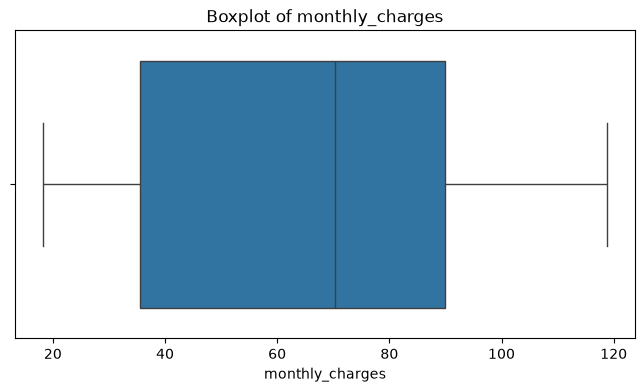

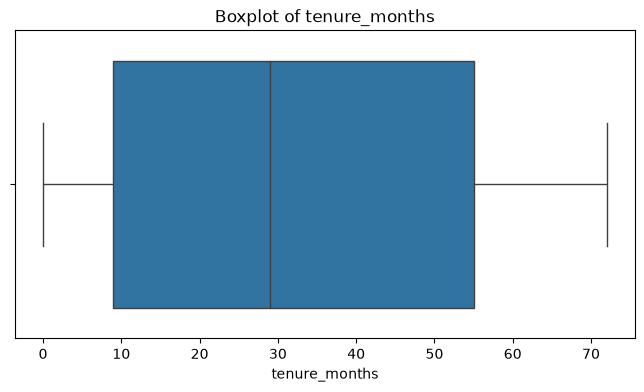

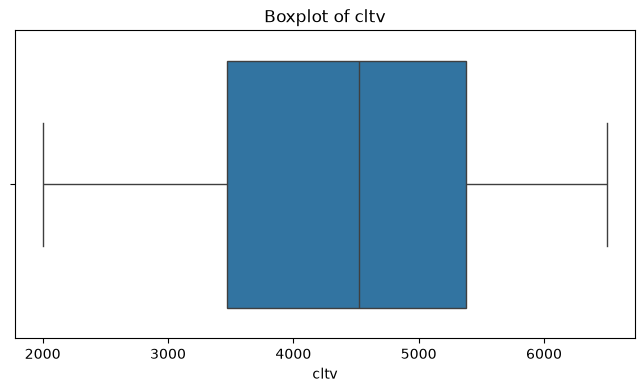

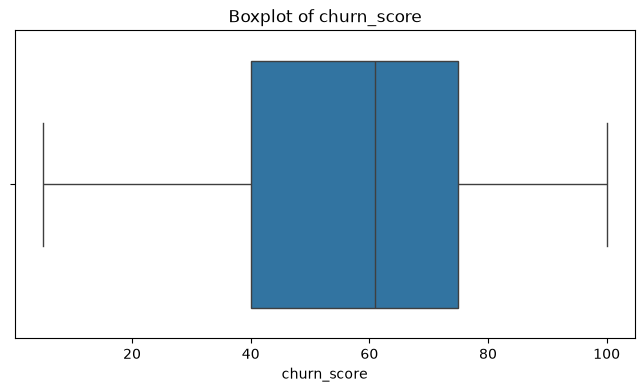

In [113]:
numerical_columns = [
    "monthly_charges",
    # "total_charges",
    "tenure_months",
    "cltv",
    "churn_score"
]

for col in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df_clean[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [114]:
df_clean["age_group"] = np.where(
    df_clean["senior_citizen"] == "Yes",
    "Senior Citizen",
    "Adult"
)

In [115]:
df_clean["monthly_spend_category"] = pd.cut(
    df_clean["monthly_charges"],
    bins=[0,35,70,130],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [116]:
df_clean["tenure_group"] = pd.cut(
    df_clean["tenure_months"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "12-24 Months",
        "24-48 Months",
        "48-72 Months"
    ]
)

In [117]:
median_cltv = df_clean["cltv"].median()

df_clean["high_value_customer"] = np.where(
    df_clean["cltv"] >= median_cltv,
    "Yes",
    "No"
)

In [118]:
df_clean["cltv_segment"] = pd.qcut(
    df_clean["cltv"],
    q=4,
    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Platinum"
    ]
)

In [119]:
df_clean["churn_risk"] = pd.qcut(
    df_clean["churn_score"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [120]:
df_clean["payment_mode"] = (
    df_clean["payment_method"]
    .astype(str)
    .replace({
        "Electronic check": "Online",
        "Credit card (automatic)": "Online",
        "Bank transfer (automatic)": "Online",
        "Mailed check": "Offline"
    })
)

In [121]:
df_clean["internet_category"] = (
    df_clean["internet_service"]
    .astype(str)
    .replace({
          "Fiber optic":"Fiber",
          "DSL":"DSL",
          "No":"No Internet"
    })
)

In [122]:
services = [
    "phone_service",
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

df_clean["service_count"] = (
    df_clean[services] == "Yes"
).sum(axis=1)

In [123]:
df_clean["engagement_score"] = (
      df_clean["tenure_months"] * 0.40
    + df_clean["service_count"] * 5
    + df_clean["cltv"] / 100
)

In [124]:
df_clean["customer_status"] = np.where(
    df_clean["churn_label"] == "Yes",
    "Inactive",
    "Active"
)

In [125]:
df_clean["location"] = (
    df_clean["city"] + ", " +
    df_clean["state"]
)

In [126]:
df_clean["total_charges"] = pd.to_numeric(
    df_clean["total_charges"],
    errors="coerce"
)

In [127]:
df_clean["avg_revenue_per_month"] = (
    df_clean["total_charges"] /
    df_clean["tenure_months"].replace(0, 1)
)

In [128]:
df_clean["coordinates"] = list(
    zip(
        df_clean["latitude"],
        df_clean["longitude"]
    )
)

In [129]:
df_clean["churn_reason_category"] = np.where(
    df_clean["churn_reason"].isna(),
    "No Churn",
    "Churned"
)

In [130]:
df_clean["loyalty_level"] = pd.cut(
    df_clean["tenure_months"],
    bins=[0,12,36,60,72],
    labels=[
        "New",
        "Regular",
        "Loyal",
        "Highly Loyal"
    ]
)

In [131]:
conditions = [
    (df_clean["high_value_customer"] == "Yes") & (df_clean["churn_risk"] == "High"),
    (df_clean["high_value_customer"] == "Yes") & (df_clean["churn_risk"] != "High"),
    (df_clean["high_value_customer"] == "No") & (df_clean["churn_risk"] == "High")
]

choices = [
    "VIP At Risk",
    "VIP",
    "At Risk"
]

df_clean["customer_segment"] = np.select(
    conditions,
    choices,
    default="Standard"
)

In [132]:
from sklearn.preprocessing import LabelEncoder

ml_df = df_clean.copy()

encoder = LabelEncoder()

for col in ml_df.select_dtypes(include=["object", "category"]):
    ml_df[col] = encoder.fit_transform(
        ml_df[col].astype(str)
    )

ml_df.to_csv(
    "data/processed/churn_encoded.csv",
    index=False
)

print("Encoded dataset saved.")

Encoded dataset saved.


In [133]:
df_clean.to_csv(
    "data/processed/churn_clean.csv",
    index=False
)

df_clean.to_excel(
    "data/processed/churn_clean.xlsx",
    index=False
)

print("Clean dataset saved.")

Clean dataset saved.


In [134]:
cleaning_summary = pd.DataFrame({

    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],

    "Value":[
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

cleaning_summary


,Metric,Value
0,Rows,7043
1,Columns,50
2,Missing Values,44
3,Duplicate Rows,0


In [135]:
cleaning_summary.to_csv(
    "reports/cleaning_summary.csv",
    index=False
)

print("Cleaning summary exported.")

Cleaning summary exported.
